# Q2 - Portfolio Effects

**Author:** Belinda (Gia Bao) Ngo

**Datasets:**
* `40B_zip_long_lat.csv` (https://drive.google.com/file/d/1n92fRXF_BWBSz2-vAPYDsduTz93VxYul/view?usp=drive_link)

* `allprice_resale_2021-25_final_latest.csv` (https://drive.google.com/file/d/1IpUgztklM5QnCD3uWqlLQXCvmdhkU8_a/view?usp=drive_link)

* `Property_Data_Jun2021_Sep2025_MissingResaleValues_Completed.csv` (https://drive.google.com/file/d/1p-OQFqu9F3LpDTWs3uAkrTu7otcww-qI/view?usp=drive_link)

**Instruction**: Download the CSV files above and move them to the `ds-chapa-affordable-housing/fa25-team-a/data` folder, then run the cells below

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Merge Applicant and Resale&Price datasets

In [2]:
# Step 1: Load datasets
# Property dataset with price & resale info
df_properties = pd.read_csv("../data/allprice_resale_2021-25_final_latest.csv")
# Applicant dataset for Chapter 40B properties
df_applicants = pd.read_csv("../data/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.3.csv")


# Step 2: Standardize columns for merging
# Function to clean text columns (strip spaces, convert to lowercase)
def clean_text(series):
    return series.astype(str).str.strip().str.lower()

# Clean property dataset columns
df_properties['Town_clean'] = clean_text(df_properties['Town'])
df_properties['Address_clean'] = clean_text(df_properties['Address'])
df_properties['Unit_clean'] = clean_text(df_properties['Unit Number'])

# Clean applicant dataset columns
df_applicants['Town_clean'] = clean_text(df_applicants['property_town_city'])
df_applicants['Address_clean'] = clean_text(df_applicants['property_street_address'])
df_applicants['Unit_clean'] = clean_text(df_applicants['property_unit'])


# Step 3: Merge applicants onto properties
merged = pd.merge(
    df_properties,
    df_applicants,
    on=['Town_clean', 'Address_clean', 'Unit_clean'],
    how='right',
    suffixes=('', '_applicant')
)

# Drop the temporary cleaned columns
merged = merged.drop(columns=['Town_clean', 'Address_clean', 'Unit_clean'])

# Save intermediate merge
merged.to_csv("../data/merged_Chapter-40B-v0.3_allprice_resale.csv", index=False)
print("Merge complete. File saved as merged_Chapter-40B-v0.3_allprice_resale.csv")

# Step 4: Add missing Maximum Resale Prices
## Load the merged dataset and new price data
merged_final = pd.read_csv("../data/merged_Chapter-40B-v0.3_allprice_resale.csv")
df_prices = pd.read_csv("../data/Property_Data_Jun2021_Sep2025_MissingResaleValues_Completed.csv")

# Rename column for clarity
df_prices = df_prices.rename(columns={"Price": "Maximum Resale Price"})

# Define keys to merge on
merge_keys = ["Town", "Address", "Unit Number"]

# Merge new prices into the dataset
merged_updated = pd.merge(
    merged_final,
    df_prices[merge_keys + ["Maximum Resale Price"]],
    on=merge_keys,
    how="left",
    suffixes=("", "_new")
)

# Fill missing prices with values from new dataset
merged_updated["Maximum Resale Price"] = merged_updated["Maximum Resale Price"].fillna(
    merged_updated["Maximum Resale Price_new"]
)

# Drop the helper column
merged_updated = merged_updated.drop(columns=["Maximum Resale Price_new"])

# Save the final dataset
merged_updated.to_csv("../data/merged_filled_Chapter-40B-v0.3_allprice_resale.csv", index=False)
print("Missing prices filled. File saved as merged_filled_Chapter-40B-v0.3_allprice_resale.csv")

Merge complete. File saved as merged_Chapter-40B-v0.3_allprice_resale.csv
Missing prices filled. File saved as merged_filled_Chapter-40B-v0.3_allprice_resale.csv


## Using Merged Applicant and Property&Price dataset

In [3]:
file_path = "../data/merged_filled_Chapter-40B-v0.3_allprice_resale.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("/", "_").str.replace("?", "")
df = df[
    (df['current_residence_town_city'] != 'Unknown') &
    (df['current_residence_state'] != 'Unknown') &
    (df['age'] != 0) &
    (~df['hh_size'].isin([0, 20, 31]))
]
print(len(df))
df = df.dropna(subset=['town'])
print(len(df))
df.head()

1614
901


,town,address,unit_number,maximum_resale_price,property_feature,development,transaction_start_date,closing_date,bedrooms,age_restricted,...,race_cleaned,race_type,race_american_indian_or_alaska_native,race_asian,race_black_or_african_american,race_hispanic_or_latino,race_middle_eastern_or_north_african,race_native_hawaiian_or_pacific_islander,race_other__prefer_not_to_answer,race_white
14,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,['White'],Single Race,0,0,0,0,0,0,0,1
15,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,['White'],Single Race,0,0,0,0,0,0,0,1
16,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,['White'],Single Race,0,0,0,0,0,0,0,1
17,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,['White'],Single Race,0,0,0,0,0,0,0,1
19,Billerica,41 Boston Road,233,"$213,200.00",NaN,Barrett Farm,7/12/21,10/28/21,2.0,No,...,"['Asian', 'Native Hawaiian or Pacific Islander']",Multiracial,0,1,0,0,0,1,0,0


## 1. Property-side demographics (supply)

**Goal:** Are certain towns or property types associated with particular demographic patterns?

### How do Applicant Ages differ by Property Town?

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_45353/2284039599.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


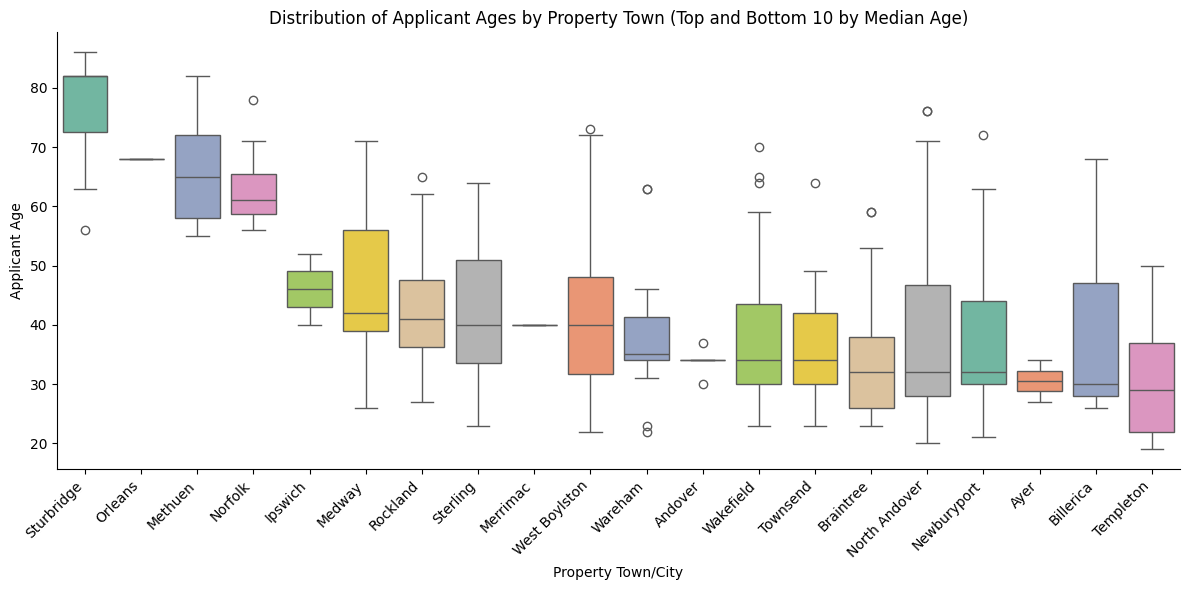

In [ ]:
# Filter: drop missing ages or locations
df_age = df[df['age'].notna() & df['property_town_city'].notna() & df['age_restricted'].notna()].copy()

# Option 1: Show top 10 and bottom 10 towns by average age
age_by_town = (
    df_age.groupby('property_town_city')['age']
    .median()
    .sort_values(ascending=False)
)
top_towns = pd.concat([age_by_town.head(10), age_by_town.tail(10)]).index
df_towns_subset = df_age[df_age['property_town_city'].isin(top_towns)]

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_towns_subset,
    x='property_town_city',
    y='age',
    order=age_by_town.loc[top_towns].index,
    palette='Set2'
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Property Town/City')
plt.ylabel('Applicant Age')
plt.title('Distribution of Applicant Ages by Property Town (Top and Bottom 10 by Median Age)')#, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()

### How do Applicant Ages differ by MSA?

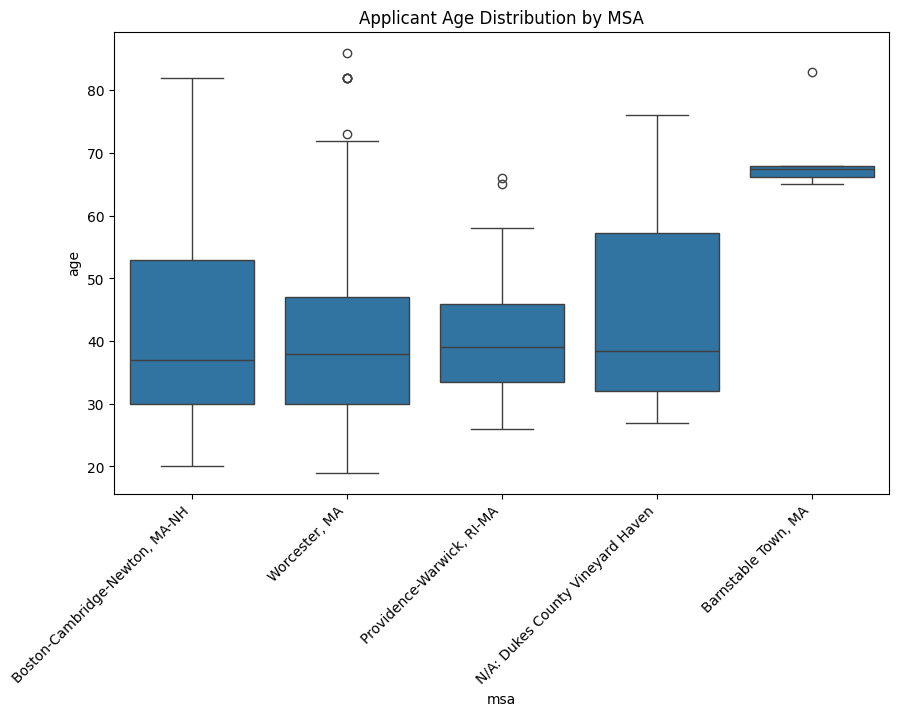

In [ ]:
df.columns.values[49]
df.columns.values[20] = 'msa_alt'
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='msa', y='age')
plt.xticks(rotation=45, ha='right')
plt.title('Applicant Age Distribution by MSA')
plt.show()
df.columns.values[20] = 'msa'

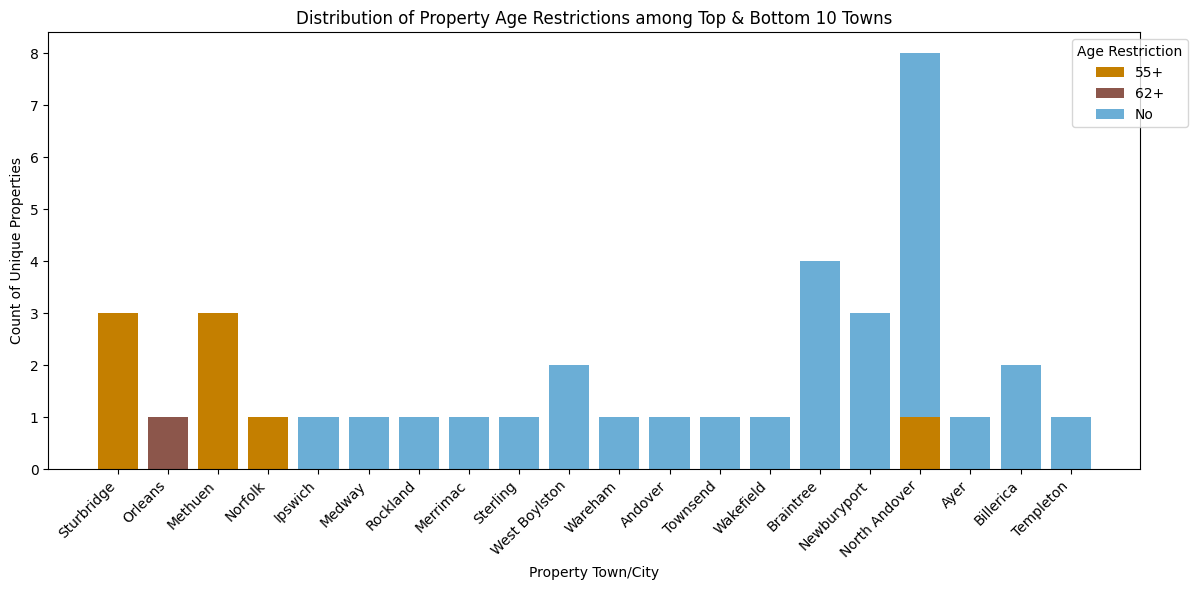

In [ ]:
df_clean = df.copy()

# Normalize key components
for col in ['property_town_city', 'property_street_address', 'property_unit']:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Create unique property key
df_clean['property_key'] = (
    df_clean['property_town_city'] + ' | ' +
    df_clean['property_street_address'] + ' | ' +
    df_clean['property_unit']
)

df_clean['age_restricted'] = (
    df_clean['age_restricted']
    .astype(str)
    .str.strip()
    .replace({'nan': None, '': None, 'None': None})
)

unique_props = (
    df_clean.groupby('property_key')
    .agg({
        'property_town_city': 'first',
        'age_restricted': lambda x: (
            '55+' if '55+' in x.values else
            ('62+' if '62+' in x.values else 'No')
        )
    })
    .reset_index()
)

age_by_town = (
    df_age.groupby('property_town_city')['age']
    .median()
    .sort_values(ascending=False)
)
towns_of_interest = pd.concat([age_by_town.head(10), age_by_town.tail(10)]).index

# Filter unique properties to those 20 towns
subset_props = unique_props[
    unique_props['property_town_city'].isin(towns_of_interest)
]

# Count properties by town × age restriction type
town_age_counts = (
    subset_props
    .groupby(['property_town_city', 'age_restricted'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

town_age_counts = (
    town_age_counts
    .merge(age_by_town.rename('median_age'), on='property_town_city', how='left')
    .sort_values('median_age', ascending=False)
)

town_age_counts

# # Melt the dataframe for plotting (long format)
# plot_df = town_age_counts.melt(
#     id_vars=['property_town_city', 'median_age'],
#     value_vars=['55+', '62+', 'No'],
#     var_name='Age Restriction',
#     value_name='Property Count'
# )

# # Plot
# plt.figure(figsize=(12,6))
# sns.barplot(
#     data=plot_df,
#     x='property_town_city',
#     y='Property Count',
#     hue='Age Restriction',
#     order=town_age_counts['property_town_city'],
#     palette=['#c47f00', '#8c564b', '#6baed6']  # custom colors: 55+, 62+, No
# )

# plt.title('Distribution of Property Age Restrictions among Top & Bottom 10 Towns', weight='bold')
# plt.xlabel('Property Town/City')
# plt.ylabel('Count of Unique Properties')
# plt.xticks(rotation=45, ha='right')
# plt.legend(title='Age Restriction', bbox_to_anchor=(1.05, 1))
# sns.despine()
# plt.tight_layout()
# plt.show()

towns = town_age_counts['property_town_city']
x = np.arange(len(towns))

# Get counts for each restriction type
counts_55 = town_age_counts['55+']
counts_62 = town_age_counts['62+']
counts_no = town_age_counts['No']

# Plot
plt.figure(figsize=(12,6))

plt.bar(x, counts_55, label='55+', color='#c47f00')
plt.bar(x, counts_62, bottom=counts_55, label='62+', color='#8c564b')
plt.bar(x, counts_no, bottom=counts_55 + counts_62, label='No', color='#6baed6')

plt.xticks(x, towns, rotation=45, ha='right')
plt.xlabel('Property Town/City')
plt.ylabel('Count of Unique Properties')
plt.title('Distribution of Property Age Restrictions among Top & Bottom 10 Towns')
plt.legend(title='Age Restriction', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Are Racial Compositions systematically different across Property Towns?

<Figure size 1200x800 with 0 Axes>

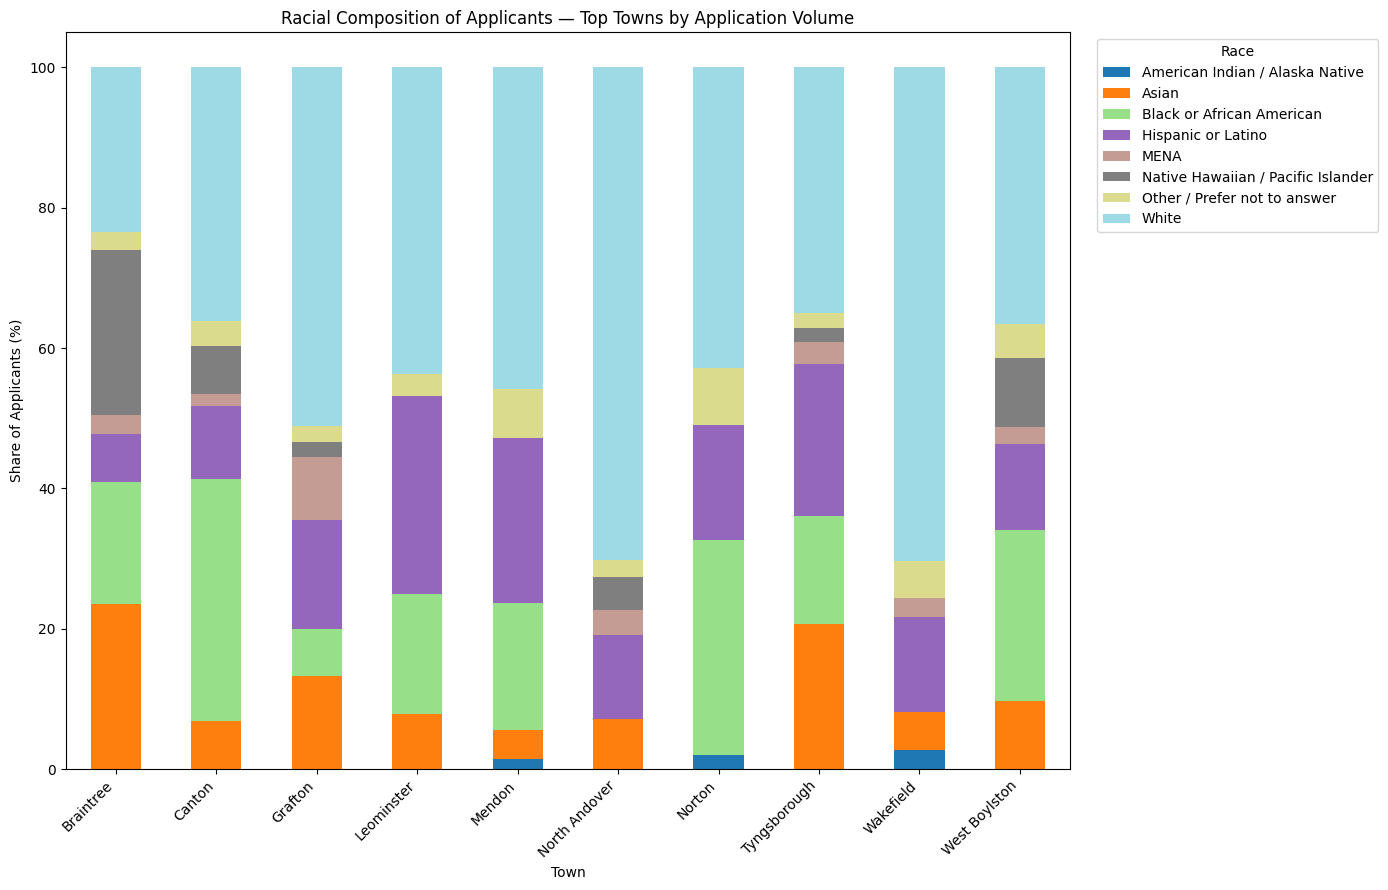

In [27]:
race_cols = [
    'race_american_indian_or_alaska_native',
    'race_asian',
    'race_black_or_african_american',
    'race_hispanic_or_latino',
    'race_middle_eastern_or_north_african',
    'race_native_hawaiian_or_pacific_islander',
    'race_other__prefer_not_to_answer',
    'race_white'
]

race_labels = [
    'American Indian / Alaska Native', 'Asian', 'Black or African American',
    'Hispanic or Latino', 'MENA',
    'Native Hawaiian / Pacific Islander', 'Other / Prefer not to answer', 'White'
]

# Compute application count per town
town_counts = (
    df.groupby('property_town_city')['application_id']
    .count()
    .sort_values(ascending=False)
)

# choose top N towns
TOP_N = 10
top_towns = town_counts.head(TOP_N).index.tolist()

# Filter to these towns
df_top = df[df['property_town_city'].isin(top_towns)]

# Aggregate racial counts
town_race = (
    df_top.groupby('property_town_city')[race_cols]
    .sum()
)

# Convert to proportions
town_race_pct = town_race.div(town_race.sum(axis=1), axis=0) * 100


plt.figure(figsize=(12, 8))

town_race_pct[race_cols].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 9),
    colormap='tab20'
)

plt.title("Racial Composition of Applicants — Top Towns by Application Volume")
plt.ylabel("Share of Applicants (%)")
plt.xlabel("Town")
plt.xticks(rotation=45, ha='right')
plt.legend(race_labels, bbox_to_anchor=(1.02, 1), loc='upper left', title="Race")
plt.tight_layout()
plt.show()

### Do Towns with More Age-Restricted Properties Have Older Applicants?

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_45353/1770454854.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_age_restricted'] = df_clean['age_restricted'].isin(['55+', '62+'])


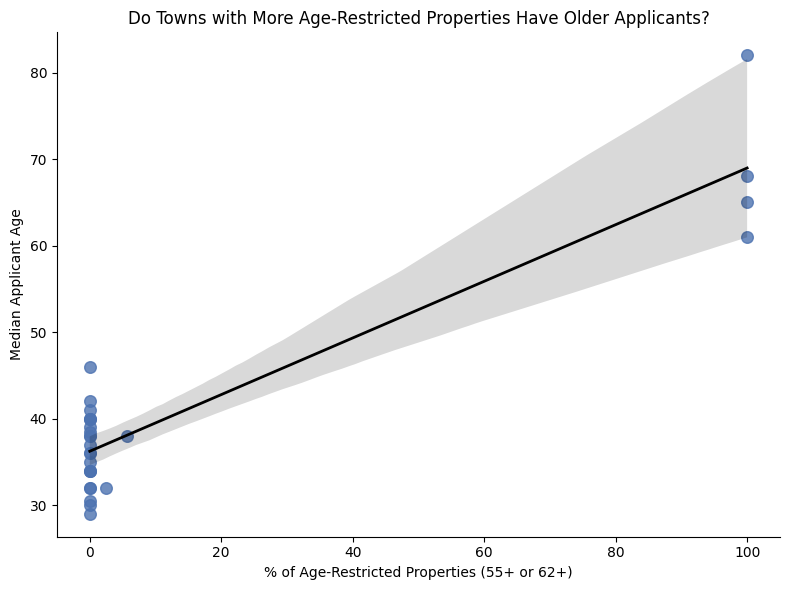

Correlation between % age-restricted and median applicant age: 0.92


In [ ]:
df_clean = df[df['property_town_city'].notna() & df['age_restricted'].notna()]

# Create a binary flag: True if 55+ or 62+, else False
df_clean['is_age_restricted'] = df_clean['age_restricted'].isin(['55+', '62+'])

# Keep rows with non-missing age and property town
df_clean = df_clean[df_clean['age'].notna() & df_clean['property_town_city'].notna()]

# Compute town-level median age
age_by_town = (
    df_clean.groupby('property_town_city')['age']
    .median()
    .reset_index()
    .rename(columns={'age': 'median_age'})
)

# Compute % of age-restricted properties by town
town_age_restricted = (
    df_clean.groupby('property_town_city')['is_age_restricted']
    .mean()
    .reset_index()
    .rename(columns={'is_age_restricted': 'pct_age_restricted'})
)

town_age_restricted['pct_age_restricted'] *= 100  # convert to %

# Merge both summaries
town_summary = (
    age_by_town
    .merge(town_age_restricted, on='property_town_city', how='left')
    .fillna({'pct_age_restricted': 0})
)

# Visualize relationship
plt.figure(figsize=(8,6))
sns.regplot(
    data=town_summary,
    x='pct_age_restricted',
    y='median_age',
    scatter_kws={'s': 70, 'alpha': 0.8, 'color': '#4C72B0'},
    line_kws={'color': 'black', 'lw': 2}
)
plt.xlabel('% of Age-Restricted Properties (55+ or 62+)')
plt.ylabel('Median Applicant Age')
plt.title('Do Towns with More Age-Restricted Properties Have Older Applicants?')
sns.despine()
plt.tight_layout()
plt.show()

# Correlation for quick test
corr = town_summary['pct_age_restricted'].corr(town_summary['median_age'])
print(f"Correlation between % age-restricted and median applicant age: {corr:.2f}")

### Are income brackets (hh_income, income_bracket) and asset levels higher for certain property locations (suburban vs urban)?

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_45353/3043918000.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


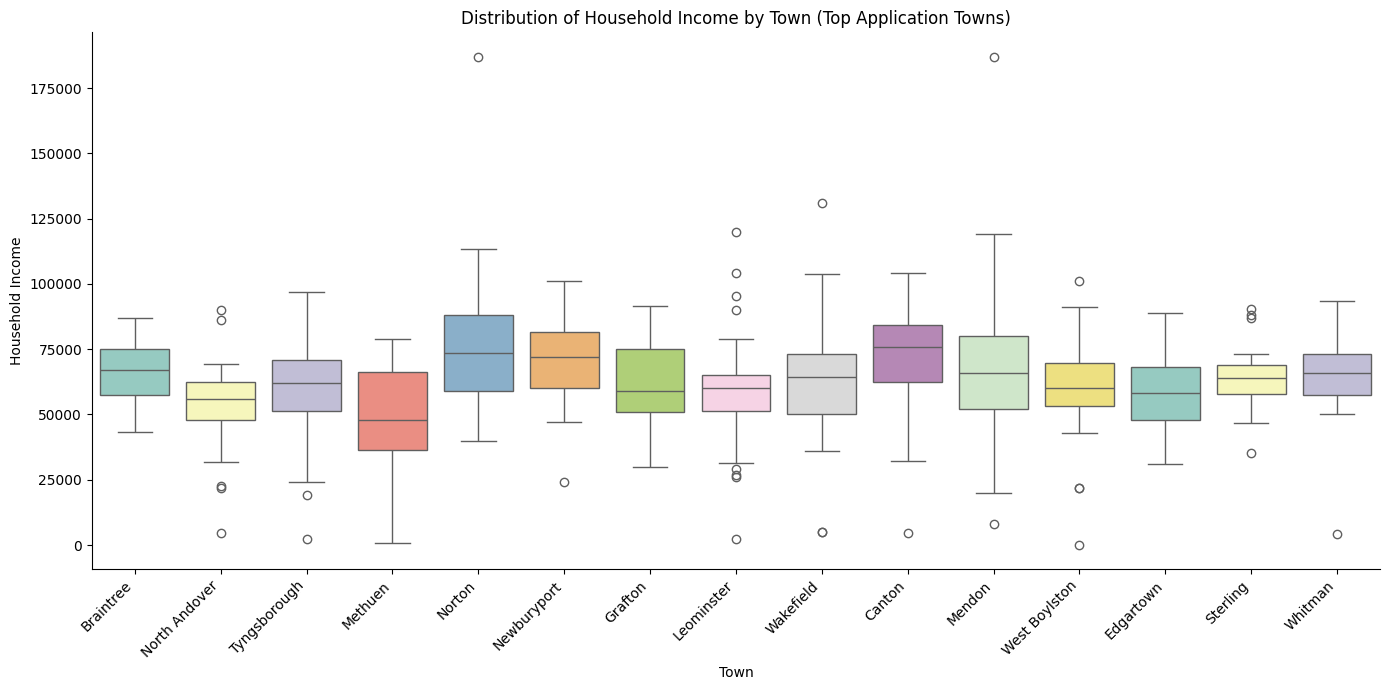

In [30]:
# Select top towns by application count
town_counts = (
    df.groupby('property_town_city')['application_id']
    .count()
    .sort_values(ascending=False)
)

TOP_N = 15
top_towns = town_counts.head(TOP_N).index.tolist()

# Filter to top towns and valid incomes
df_income = df[
    df['property_town_city'].isin(top_towns) &
    df['hh_income'].notna()
].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_income,
    x='property_town_city',
    y='hh_income',
    palette='Set3'
)

plt.title("Distribution of Household Income by Town (Top Application Towns)")
plt.xlabel("Town")
plt.ylabel("Household Income")
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

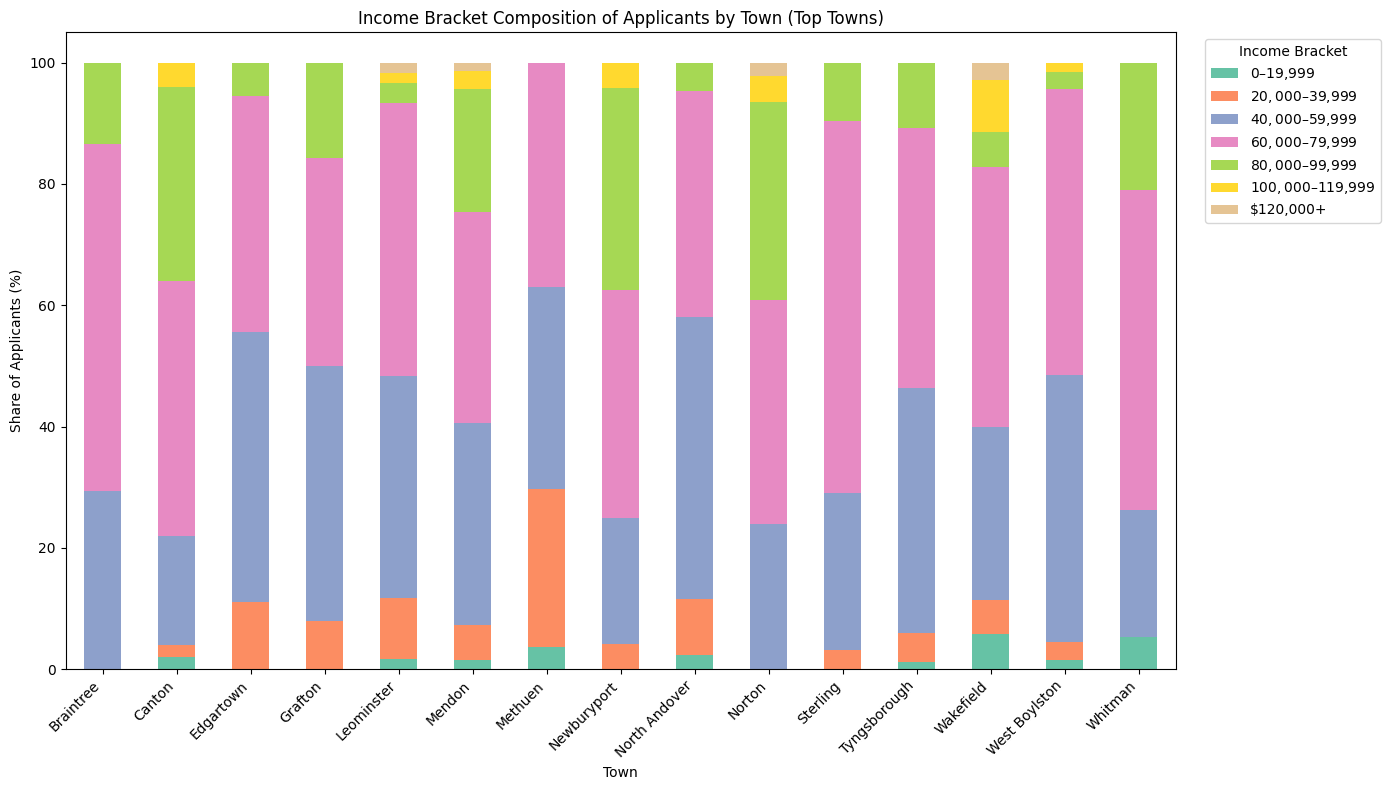

In [37]:
# Define correct chronological order
income_order = [
    '$0–$19,999',
    '$20,000–$39,999',
    '$40,000–$59,999',
    '$60,000–$79,999',
    '$80,000–$99,999',
    '$100,000–$119,999',
    '$120,000+'
]

# Ensure pivot table follows the ordered categories
pivot_income = pivot_income[income_order]

# Convert to percentages
pivot_income_pct = pivot_income.div(pivot_income.sum(axis=1), axis=0) * 100

# Color palette (gradient)
colors = sns.color_palette("Set2", len(income_order))

plt.figure(figsize=(14, 8))

# Stacked bar plot using the ordered gradient colors
ax = pivot_income_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    color=colors
)

plt.title("Income Bracket Composition of Applicants by Town (Top Towns)")
plt.ylabel("Share of Applicants (%)")
plt.xlabel("Town")
plt.xticks(rotation=45, ha='right')
plt.legend(
    title="Income Bracket",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    labels=income_order
)
plt.tight_layout()
plt.show()

## 2. Applicant-side choice patterns (demand)

**Goal:** Do different demographic groups apply to different types of properties?

### Race vs. Property restriction

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_45353/4065527985.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_source['age_restricted'] = (


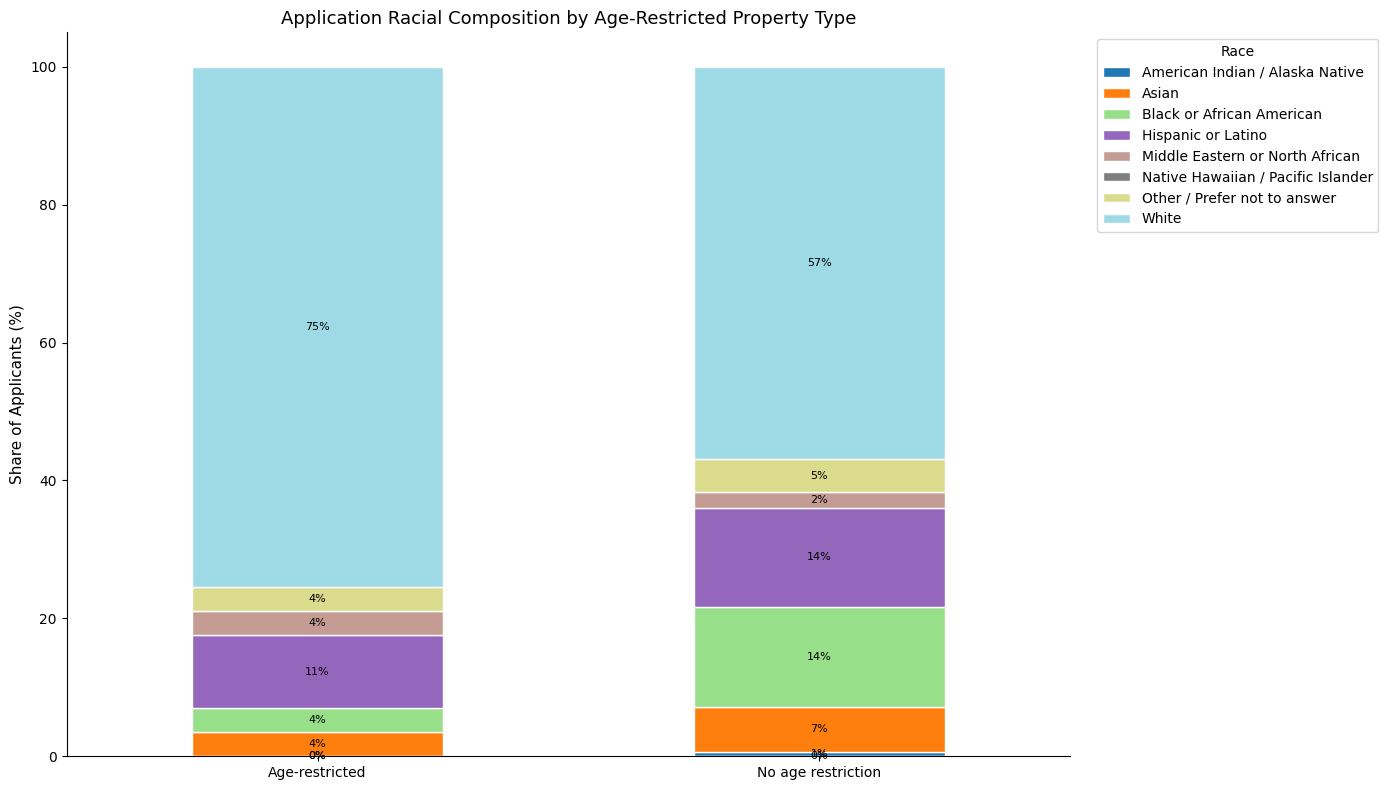

In [ ]:
# Filter to relevant subset
df_source = df[df['age_restricted'].notna() & (df['race_type'] == 'Single Race')]

df_source['age_restricted'] = (
    df_source['age_restricted']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        '55+': 'Age-restricted',
        '62+': 'Age-restricted',
        'no': 'No age restriction',
        'nan': None,
        '': None,
        'none': None
    })
)

race_cols = [
    'race_american_indian_or_alaska_native',
    'race_asian',
    'race_black_or_african_american',
    'race_hispanic_or_latino',
    'race_middle_eastern_or_north_african',
    'race_native_hawaiian_or_pacific_islander',
    'race_other__prefer_not_to_answer',
    'race_white'
]

# Aggregate and compute within-group percentages
source_race = (
    df_source.groupby('age_restricted')[race_cols]
    .sum()
    .reset_index()
)

source_race_pct = source_race.copy()
source_race_pct[race_cols] = (
    source_race[race_cols]
    .div(source_race[race_cols].sum(axis=1), axis=0) * 100
)

# Define cleaner race labels
race_labels = [
    'American Indian / Alaska Native', 'Asian', 'Black or African American',
    'Hispanic or Latino', 'Middle Eastern or North African',
    'Native Hawaiian / Pacific Islander', 'Other / Prefer not to answer', 'White'
]

# Use seaborn color palette for clarity
colors = sns.color_palette("Set2", len(race_cols))

# Plot
ax = source_race_pct.set_index('age_restricted')[race_cols].plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap = 'tab20',
    edgecolor='white'
)

# Style tweaks
ax.set_ylabel('Share of Applicants (%)', fontsize=11)
ax.set_xlabel('')
ax.set_title('Application Racial Composition by Age-Restricted Property Type', fontsize=13)#, weight='bold')
ax.legend(race_labels, title='Race', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels inside bars (optional, can comment out if cluttered)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='black', fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

### Are certain Races applying to properties in the same Town/City?

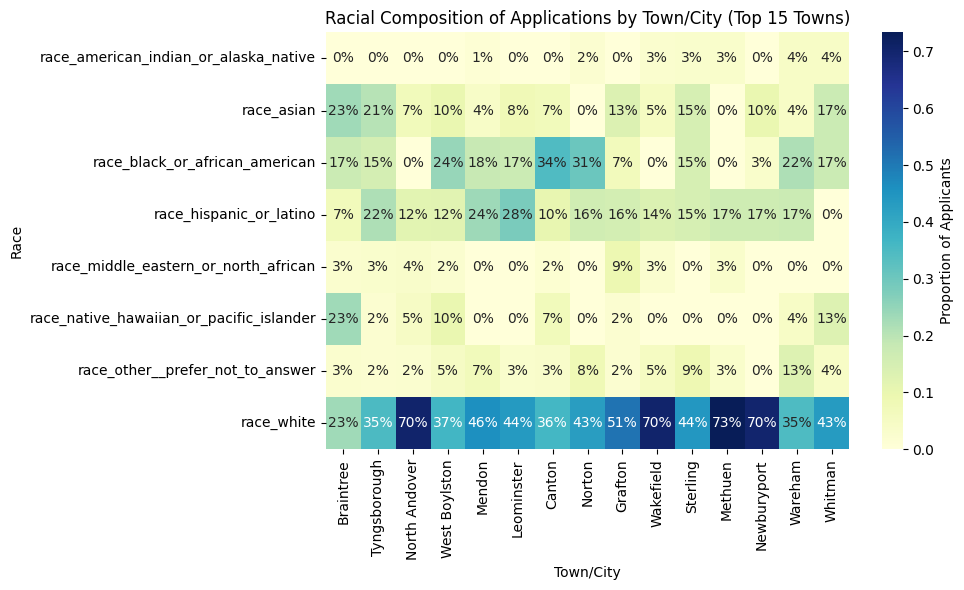

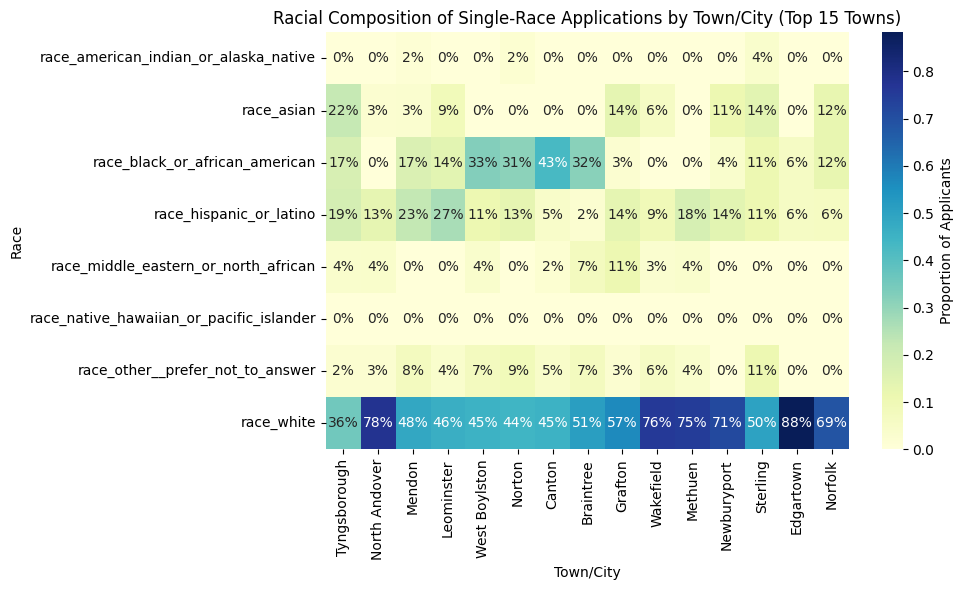

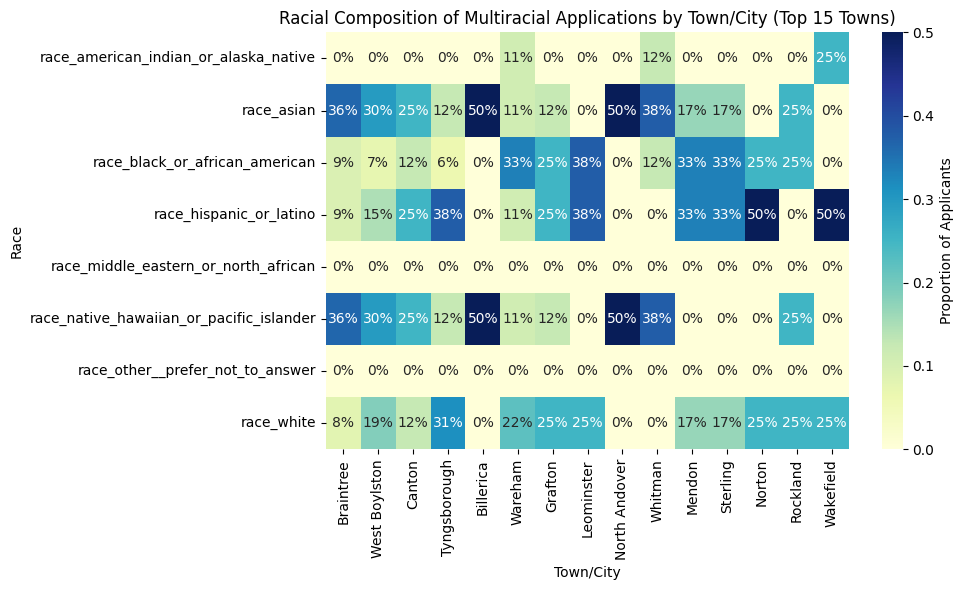

In [38]:
race_cols = df.columns.to_list()[-8:]

# Aggregate race counts per town
race_by_town = df.groupby('property_town_city')[race_cols].sum()

# Get total applicants per town
race_by_town['total_applicants'] = race_by_town.sum(axis=1)

# Compute racial proportions (optional, for heatmap)
race_share = race_by_town[race_cols].div(race_by_town['total_applicants'], axis=0)

# Keep only top towns by total applicants for cleaner viz
top_towns = race_by_town.nlargest(15, 'total_applicants').index
race_share_top = race_share.loc[top_towns]

plt.figure(figsize=(10,6))
sns.heatmap(
    race_share_top.T,
    cmap="YlGnBu",
    annot=True,
    fmt=".0%",
    cbar_kws={'label': 'Proportion of Applicants'}
)
plt.title("Racial Composition of Applications by Town/City (Top 15 Towns)")
plt.xlabel("Town/City")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

# Single Race only
# Aggregate race counts per town
race_by_town = df[df['race_type'] == 'Single Race'].groupby('property_town_city')[race_cols].sum()

# Get total applicants per town
race_by_town['total_applicants'] = race_by_town.sum(axis=1)

# Compute racial proportions (optional, for heatmap)
race_share = race_by_town[race_cols].div(race_by_town['total_applicants'], axis=0)

# Keep only top towns by total applicants for cleaner viz
top_towns = race_by_town.nlargest(15, 'total_applicants').index
race_share_top = race_share.loc[top_towns]

plt.figure(figsize=(10,6))
sns.heatmap(
    race_share_top.T,
    cmap="YlGnBu",
    annot=True,
    fmt=".0%",
    cbar_kws={'label': 'Proportion of Applicants'}
)
plt.title("Racial Composition of Single-Race Applications by Town/City (Top 15 Towns)")
plt.xlabel("Town/City")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

# Multiracial only
# Aggregate race counts per town
race_by_town = df[df['race_type'] == 'Multiracial'].groupby('property_town_city')[race_cols].sum()

# Get total applicants per town
race_by_town['total_applicants'] = race_by_town.sum(axis=1)

# Compute racial proportions (optional, for heatmap)
race_share = race_by_town[race_cols].div(race_by_town['total_applicants'], axis=0)

# Keep only top towns by total applicants for cleaner viz
top_towns = race_by_town.nlargest(15, 'total_applicants').index
race_share_top = race_share.loc[top_towns]

plt.figure(figsize=(10,6))
sns.heatmap(
    race_share_top.T,
    cmap="YlGnBu",
    annot=True,
    fmt=".0%",
    cbar_kws={'label': 'Proportion of Applicants'}
)
plt.title("Racial Composition of Multiracial Applications by Town/City (Top 15 Towns)")
plt.xlabel("Town/City")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

### Count/Proportion of First-time Homebuyers by Town

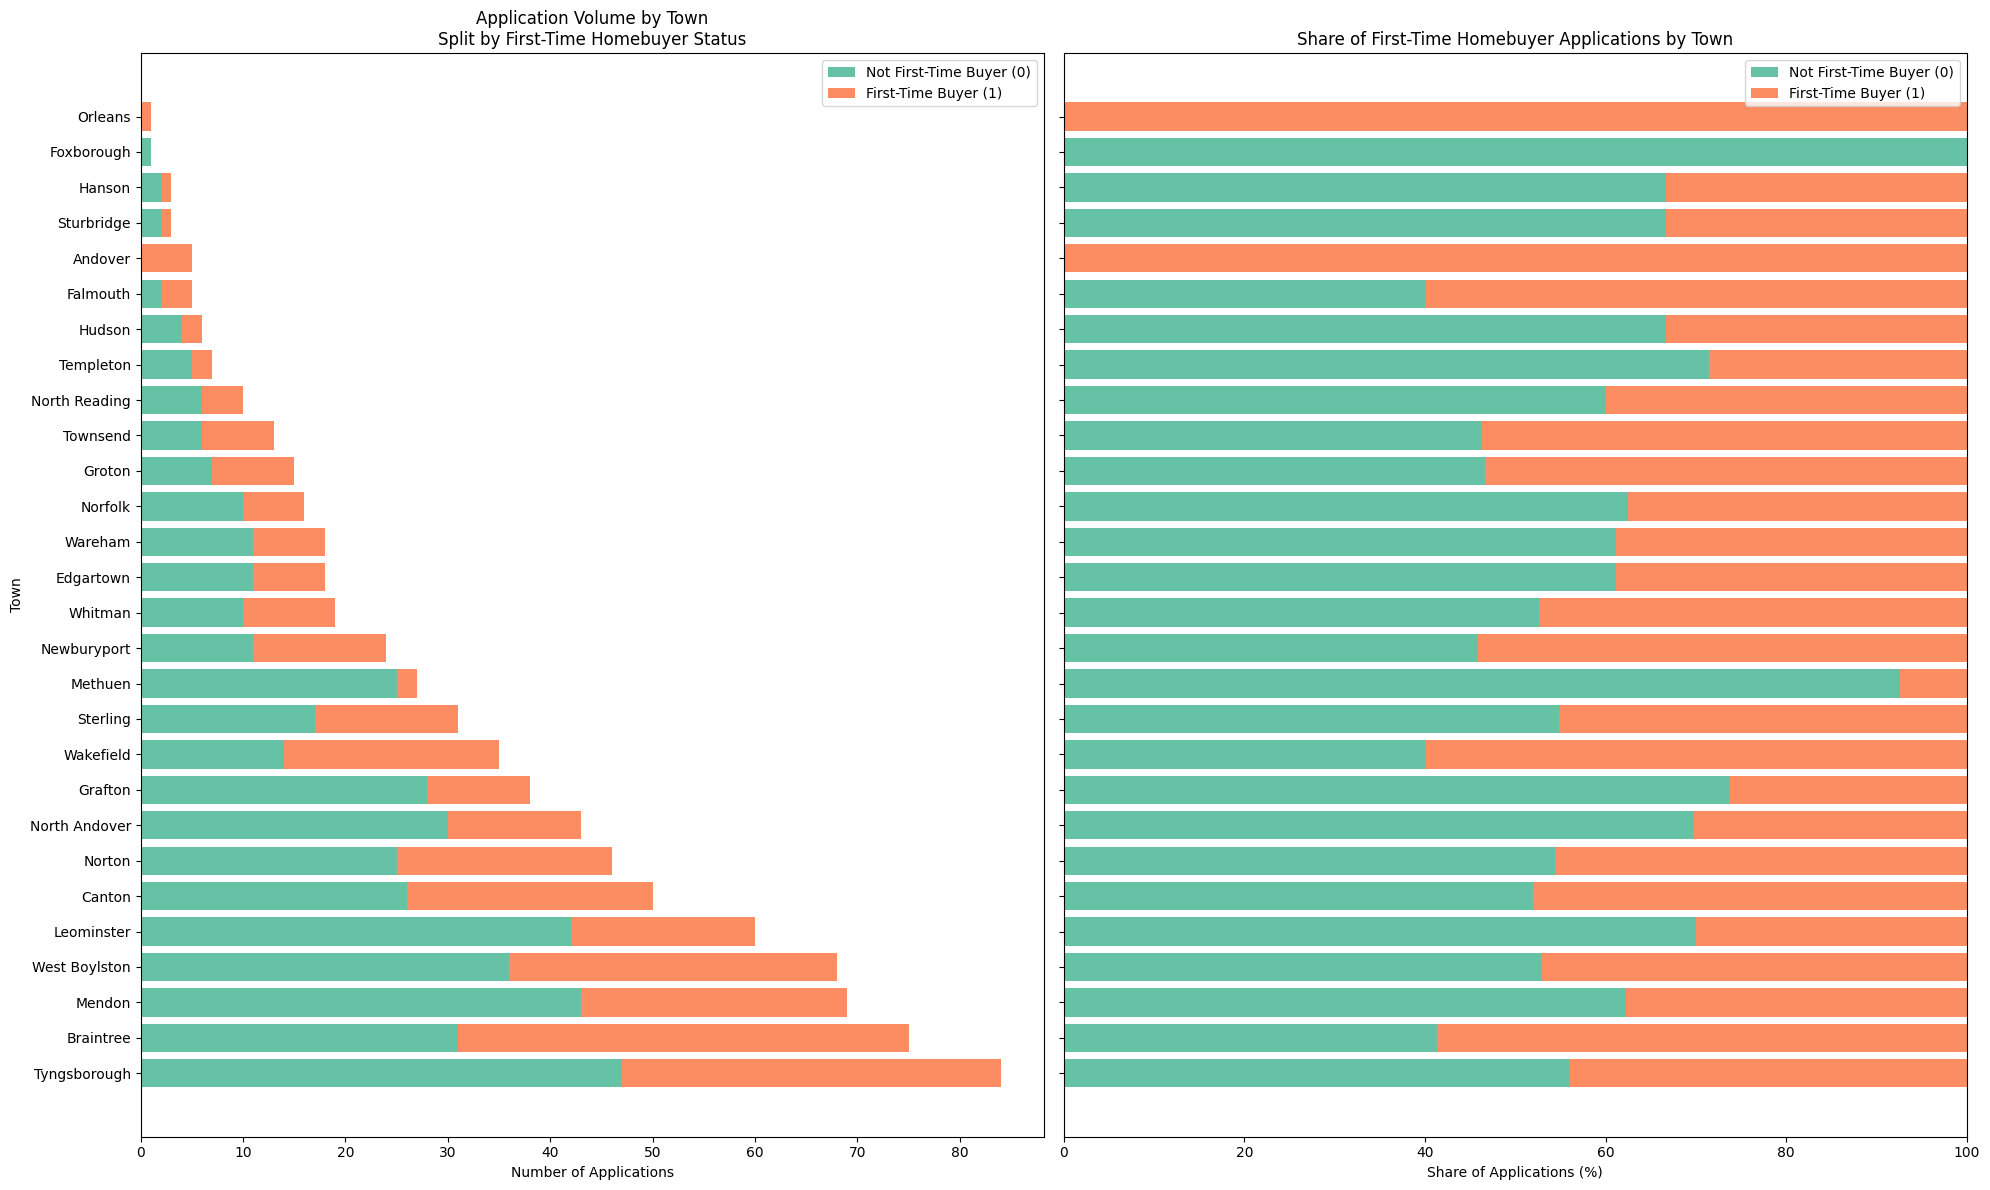

In [45]:
# Compute aggregated data
town_fthb = (
    df.groupby(['property_town_city', 'fthb_class'])['application_id']
    .count()
    .reset_index(name='application_count')
)

# Pivot for counts
pivot_counts = town_fthb.pivot(
    index='property_town_city',
    columns='fthb_class',
    values='application_count'
)

# Fill missing values with 0
pivot_counts = pivot_counts.fillna(0)

# Filter out towns where both classes have zero applications
pivot_counts = pivot_counts[(pivot_counts[0] + pivot_counts[1]) > 0]

# Recompute total applications for sorting
pivot_counts['total'] = pivot_counts[0] + pivot_counts[1]
pivot_counts = pivot_counts.sort_values('total', ascending=False)

# Compute proportions safely
pivot_props = pivot_counts.copy()
pivot_props['pct_nonfthb'] = pivot_props[0] / pivot_props['total'] * 100
pivot_props['pct_fthb'] = pivot_props[1] / pivot_props['total'] * 100

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(20, 12), sharey=True)
colors = sns.color_palette("Set2", 2)

# Chart 1: counts
axes[0].barh(pivot_counts.index, pivot_counts[0], color=colors[0], label='Not First-Time Buyer (0)')
axes[0].barh(pivot_counts.index, pivot_counts[1], 
             left=pivot_counts[0], color=colors[1],
             label='First-Time Buyer (1)')

axes[0].set_title("Application Volume by Town\nSplit by First-Time Homebuyer Status")
axes[0].set_xlabel("Number of Applications")
axes[0].set_ylabel("Town")
axes[0].legend()

# Chart 2: percentages
axes[1].barh(pivot_props.index, pivot_props['pct_nonfthb'], color=colors[0], label='Not First-Time Buyer (0)')
axes[1].barh(pivot_props.index, pivot_props['pct_fthb'], color=colors[1],
             left=pivot_props['pct_nonfthb'],
             label='First-Time Buyer (1)')

axes[1].set_title("Share of First-Time Homebuyer Applications by Town")
axes[1].set_xlabel("Share of Applications (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Are more older applicants generally applying to Age-restricted properties?

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_45353/966103131.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_45353/966103131.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


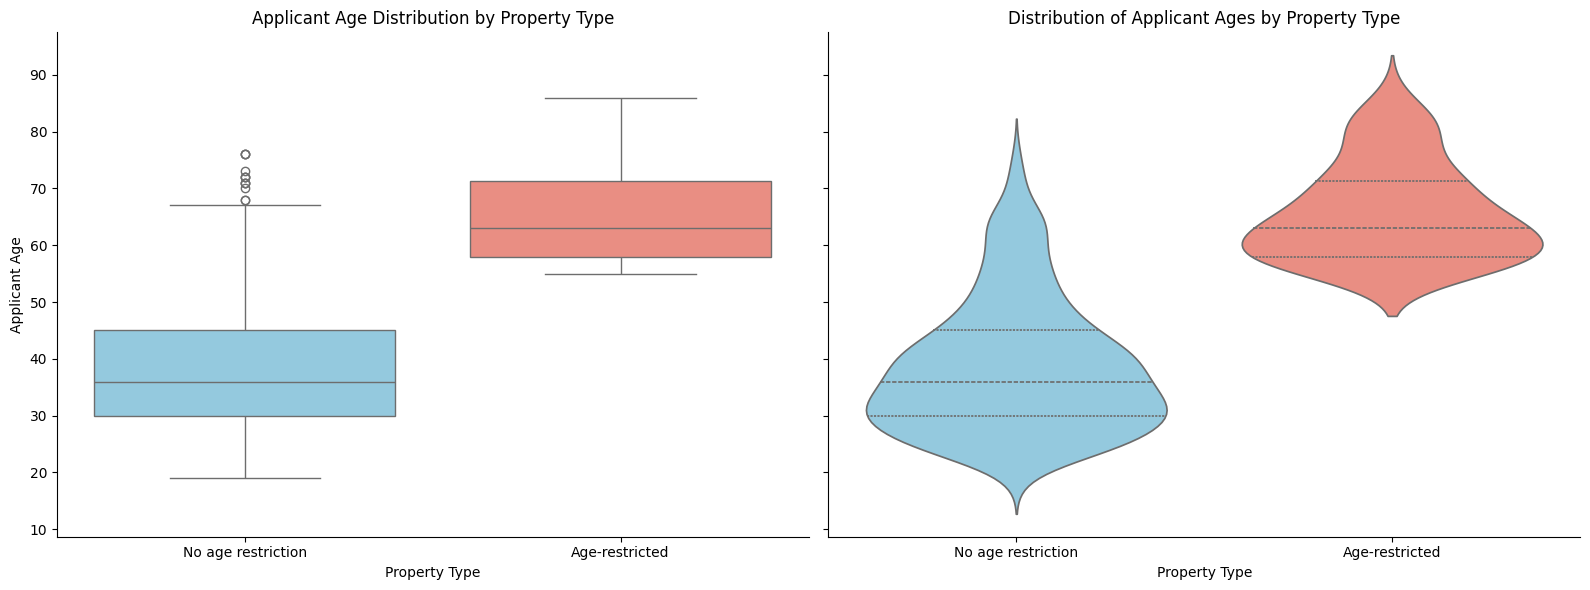

In [53]:
df_plot = df.copy()
df_plot['age_restricted'] = df_plot['age_restricted'].astype(str).str.strip().str.lower().replace({
    '55+': 'Age-restricted',
    '62+': 'Age-restricted',
    'no': 'No age restriction',
    'nan': None,
    'none': None,
    '': None
})

df_plot = df_plot[df_plot['age'].notna() & df_plot['age_restricted'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Boxplot
sns.boxplot(
    data=df_plot,
    x='age_restricted',
    y='age',
    palette=['skyblue','salmon'],
    ax=axes[0]
)
axes[0].set_title("Applicant Age Distribution by Property Type")
axes[0].set_xlabel("Property Type")
axes[0].set_ylabel("Applicant Age")
sns.despine(ax=axes[0])

# Violin plot
sns.violinplot(
    data=df_plot,
    x='age_restricted',
    y='age',
    palette=['skyblue','salmon'],
    inner='quartile',
    ax=axes[1]
)
axes[1].set_title("Distribution of Applicant Ages by Property Type")
axes[1].set_xlabel("Property Type")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

The width of the violin reflects the density of applicants at each age.

### 3. Comparing applicant pool vs property pool

**Goal:** Is the demographic mix of applicants explained by the properties offered?

### Racial Composition across Property Towns

<Figure size 1400x600 with 0 Axes>

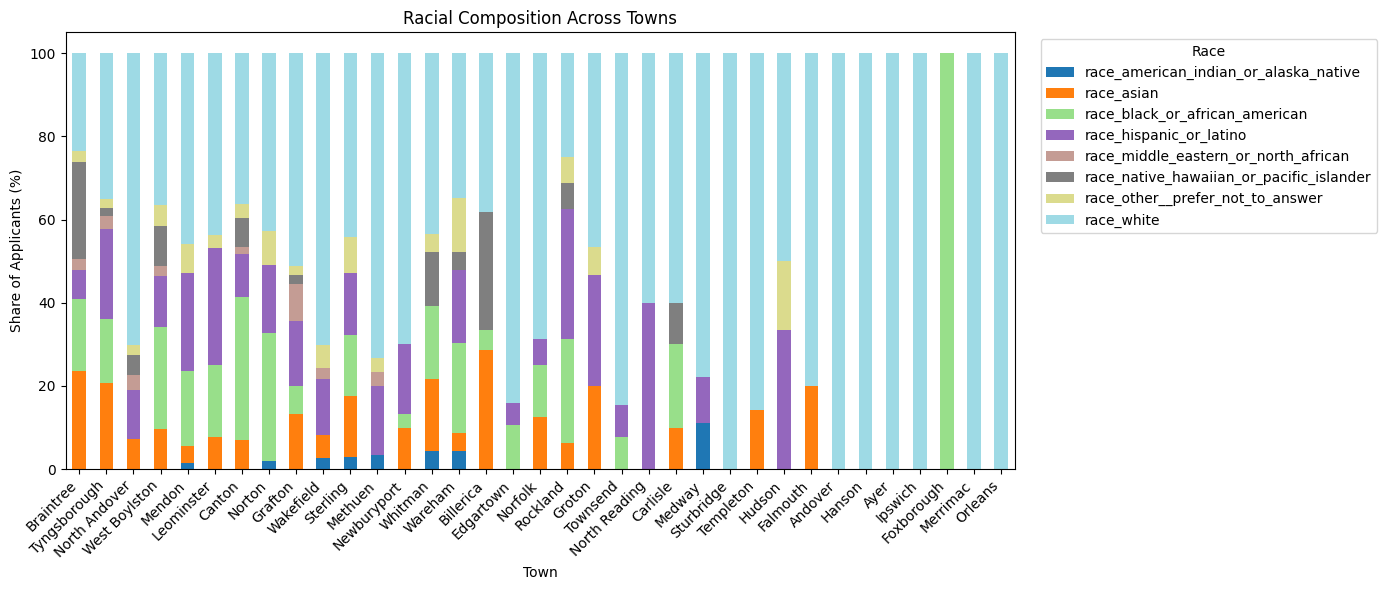

In [61]:
# Group by town and sum race counts
town_race = df.groupby('property_town_city')[race_cols].sum()

# Convert counts to proportions
town_race_pct = town_race.div(town_race.sum(axis=1), axis=0) * 100

# Optional: sort towns by total applications
town_race_pct['total'] = town_race.sum(axis=1)
town_race_pct = town_race_pct.sort_values('total', ascending=False)
town_race_pct = town_race_pct.drop(columns='total')

plt.figure(figsize=(14,6))
town_race_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6),
    colormap='tab20'  # high-contrast colors for multiple categories
)

plt.ylabel("Share of Applicants (%)")
plt.xlabel("Town")
plt.title("Racial Composition Across Towns")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Race', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

### Are demographics within each town consistent across properties, or do certain properties attract distinct subgroups?

In [75]:
def race_by_town(town):
    # Ensure each property is unique
    df['property_key'] = (
        df['property_town_city'].astype(str).str.strip() + ' | ' +
        df['property_street_address'].astype(str).str.strip() + ' | ' +
        df['property_unit'].astype(str).str.strip()
    )

    # Filter for one town to focus (or loop over towns)
    town = town
    df_town = df[df['property_town_city'] == town]

    # Columns for race (binary indicators)
    race_cols = [
        'race_american_indian_or_alaska_native',
        'race_asian',
        'race_black_or_african_american',
        'race_hispanic_or_latino',
        'race_middle_eastern_or_north_african',
        'race_native_hawaiian_or_pacific_islander',
        'race_other__prefer_not_to_answer',
        'race_white'
    ]

    # Aggregate counts per property
    property_race = df_town.groupby('property_key')[race_cols].sum()

    # Convert counts to proportions per property
    property_race_pct = property_race.div(property_race.sum(axis=1), axis=0) * 100

    # sort properties by total applications
    property_race_pct['total'] = property_race.sum(axis=1)
    property_race_pct = property_race_pct.sort_values('total', ascending=False)
    property_race_pct = property_race_pct.drop(columns='total')

    # Plot stacked bar chart
    plt.figure(figsize=(14, 6))
    property_race_pct.plot(
        kind='bar',
        stacked=True,
        figsize=(14,6),
        colormap='tab20'  # high-contrast for multiple categories
    )

    plt.ylabel("Share of Applicants (%)")
    plt.xlabel("Property")
    plt.title(f"Racial Composition Across Properties in {town}")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Race', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
# Create a unique property key
df['property_key'] = (
    df['property_town_city'].astype(str).str.strip() + ' | ' +
    df['property_street_address'].astype(str).str.strip() + ' | ' +
    df['property_unit'].astype(str).str.strip()
)

# Count unique properties
n_properties = df['property_key'].nunique()

town_property_counts = df.groupby('property_town_city')['property_key'].nunique().reset_index()
town_property_counts = town_property_counts.rename(columns={'property_key':'n_properties'})
town_property_counts

,property_town_city,n_properties
0,Andover,1
1,Ayer,1
2,Billerica,2
3,Braintree,4
4,Canton,1
5,Carlisle,1
6,Edgartown,1
7,Falmouth,2
8,Foxborough,1
9,Grafton,3


<Figure size 1400x600 with 0 Axes>

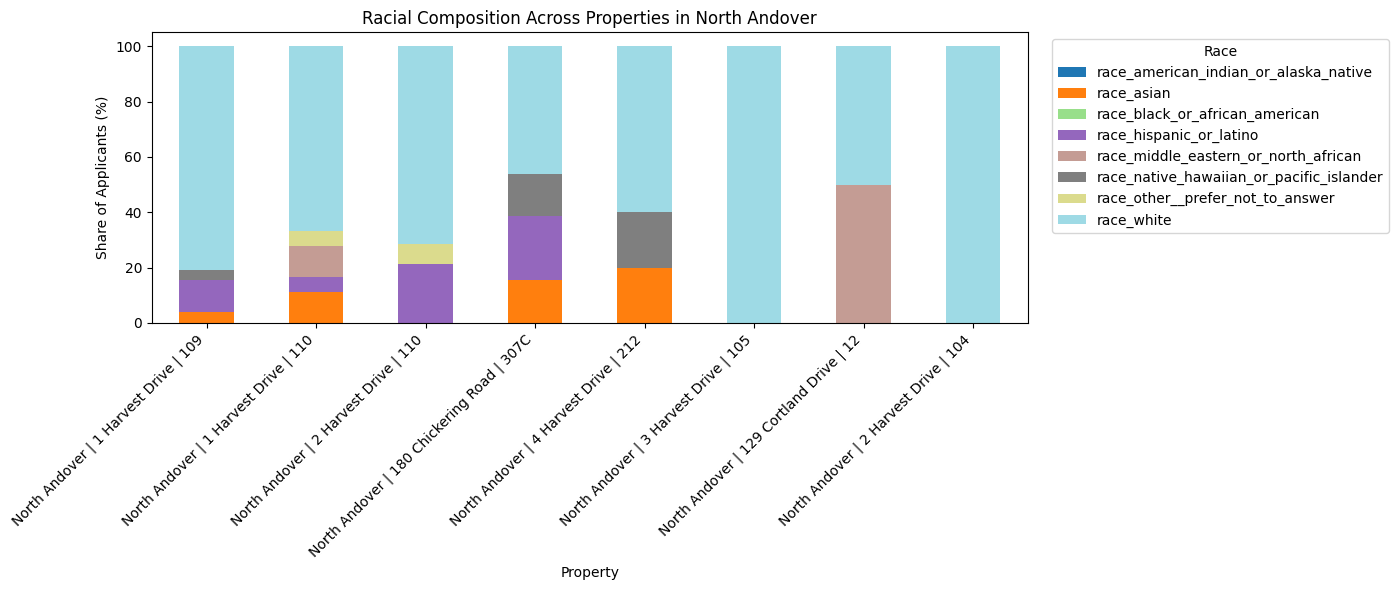

In [69]:
town = 'North Andover'
race_by_town(town)

<Figure size 1400x600 with 0 Axes>

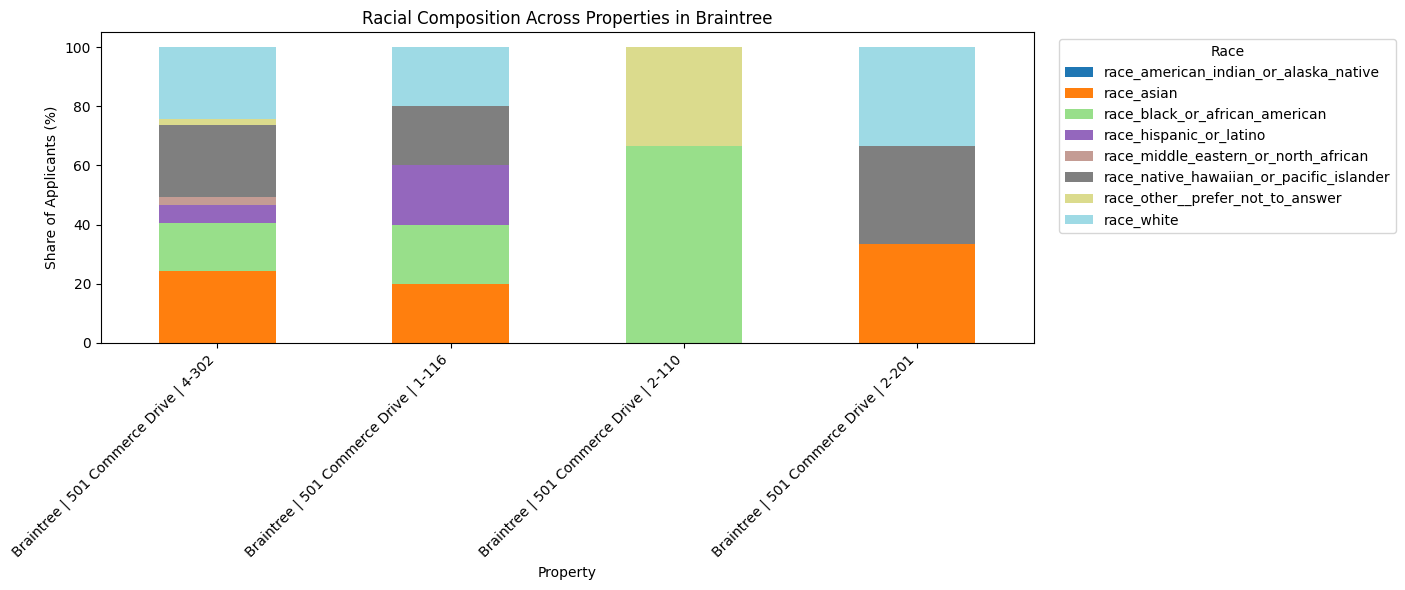

In [70]:
town = 'Braintree'
race_by_town(town)